# Ranking solar-eólico de las provincias de la República Dominicana
### Extracción y análisis de datos — Modelo Entropía-TOPSIS / CRITIC-TOPSIS

Este notebook reproduce, paso a paso, la extracción y el análisis de datos del artículo:

> *Optimización multicriterio para la priorización territorial del potencial solar y eólico: un ranking de las provincias de la República Dominicana mediante Entropía-TOPSIS*.

**Qué hace este notebook**

1. **Extracción de datos** (Parte 1)
   - Estadística zonal real sobre los ráster del *Global Solar Atlas* (GHI, DNI, GTI, PVOUT, temperatura) para las 32 provincias, usando `rasterio` + `geopandas` + `rasterstats` — reproduce la metodología descrita en la sección 3.1 del artículo.
   - Carga de los datos eólicos provinciales publicados por Vallejo Díaz et al. (2024).
   - Carga y agregación de los datos de generación eléctrica del SIEN/CNE (`GeneracionFuenteSENI.xlsx` y los archivos `Generación y Consumo en Estación *.xlsx`), usados como contexto y como validación cruzada con los parques eólicos reales.
   - Consolidación de la matriz de decisión (32 provincias × 4 criterios).

2. **Análisis multicriterio** (Parte 2)
   - Estadística descriptiva y coeficiente de variación de cada criterio (Tabla 1 del artículo).
   - Normalización vectorial, pesos por **entropía de Shannon**, pesos **CRITIC** y pesos **igualitarios**.
   - Procedimiento **TOPSIS** completo (soluciones ideal/antiideal, coeficiente de proximidad Ci) bajo los tres esquemas de ponderación.
   - Matriz de correlación de Pearson entre criterios.
   - Análisis de robustez mediante correlación de rangos de **Spearman**.
   - Validación cruzada con la ubicación real de los parques eólicos operativos.

3. **Visualización** (Parte 3) y **exportación de resultados** (Parte 4).

**Requisitos:** `pandas`, `numpy`, `scipy`, `matplotlib`, `openpyxl`. Para la extracción raster real (opcional, con reserva automática si no está disponible): `rasterio`, `geopandas`, `rasterstats`.

```
pip install pandas numpy scipy matplotlib openpyxl rasterio geopandas rasterstats xlsxwriter
```


In [2]:
# --- Librerías estándar de análisis de datos ---
import warnings
import zipfile
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --- Librerías geoespaciales (opcionales) para la extracción raster real ---
# Si no están instaladas, la Parte 1.2 se salta automáticamente y el notebook
# sigue funcionando con la matriz de decisión publicada en el artículo.
try:
    import rasterio
    from rasterio.mask import mask as rio_mask
    import geopandas as gpd
    from rasterstats import zonal_stats
    HAS_GIS = True
except ImportError:
    HAS_GIS = False
    print("rasterio/geopandas/rasterstats no están instalados: la Parte 1.2 "
          "(extracción raster) se omitirá y se usará la matriz publicada.")

print("Librerías cargadas. HAS_GIS =", HAS_GIS)


Librerías cargadas. HAS_GIS = True


## Configuración

Ajusta `DATA_DIR` si el notebook no está guardado en la misma carpeta que los archivos de datos
(`ENERLAC`). Por defecto se asume que el notebook vive junto a los archivos originales.

In [3]:
# Carpeta donde están los archivos de datos (ajustar si es necesario)
DATA_DIR = Path(".")

# Archivos de generación eléctrica (SIEN/CNE)
F_GENERACION_FUENTE = DATA_DIR / "GeneracionFuenteSENI.xlsx"
F_GENERACION_ESTACION = {
    2024: DATA_DIR / "Generaci_n y Consumo en Estaci_n 2024.xlsx",
    2025: DATA_DIR / "Generaci_n y Consumo en Estaci_n 2025.xlsx",
    2026: DATA_DIR / "Generaci_n y Consumo en Estaci_n 2026.xlsx",
}

# Archivos ráster del Global Solar Atlas (paquete GEOTIFF v1 y AAIGRID v2)
F_GSA_AAIGRID_ZIP = DATA_DIR / "Dominican-Republic_GISdata_LTAym_AvgDailyTotals_GlobalSolarAtlas-v2_AAIGRID.zip"
F_GSA_GEOTIFF_ZIP = DATA_DIR / "Dominican-Republic_GISdata_LTAy_DailySum_GlobalSolarAtlas_GEOTIFF.zip"

# Carpeta de trabajo temporal para los ráster descomprimidos y de resultados
WORK_DIR = DATA_DIR / "_notebook_tmp"
OUT_DIR = DATA_DIR / "outputs"
WORK_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

for label, f in {"GeneracionFuenteSENI": F_GENERACION_FUENTE,
                  "GSA AAIGRID": F_GSA_AAIGRID_ZIP,
                  "GSA GEOTIFF": F_GSA_GEOTIFF_ZIP}.items():
    print(f"{'[OK]' if f.exists() else '[NO ENCONTRADO]':16s} {label}: {f}")


[OK]             GeneracionFuenteSENI: GeneracionFuenteSENI.xlsx
[NO ENCONTRADO]  GSA AAIGRID: Dominican-Republic_GISdata_LTAym_AvgDailyTotals_GlobalSolarAtlas-v2_AAIGRID.zip
[NO ENCONTRADO]  GSA GEOTIFF: Dominican-Republic_GISdata_LTAy_DailySum_GlobalSolarAtlas_GEOTIFF.zip


## PARTE 1 — Extracción de datos

### 1.1 Matriz de decisión publicada (Apéndice A del artículo)

La fuente primaria de este estudio es la **estadística zonal** de los ráster del Global Solar Atlas
(Solargis/ESMAP-Banco Mundial, 2020) para el recurso solar, y el estudio provincial de
**Vallejo Díaz et al. (2024)** para el recurso eólico (velocidad a 10 m y potencial energético
específico, derivados de reanálisis NASA POWER 2011-2021). Estos son exactamente los 32
valores publicados en el Apéndice A del artículo; se transcriben aquí para tener, desde el primer
momento, una matriz de decisión completa, verificable y reproducible, independientemente de que
la extracción raster de la sección 1.2 esté o no disponible en el entorno de ejecución.

In [4]:
# --- Recurso solar: Tabla 5 del Apéndice A (Global Solar Atlas, zonal stats por provincia) ---
SOLAR_CSV = StringIO('''provincia,GHI,DNI,GTI,PVOUT,TEMP
Azua,5.668,5.427,5.970,4.653,23.8
Bahoruco,5.746,5.550,6.061,4.656,25.6
Barahona,5.645,5.381,5.927,4.570,23.7
Dajabon,5.544,5.163,5.837,4.473,26.3
Distrito Nacional,5.503,5.007,5.772,4.460,23.1
Duarte,5.272,4.571,5.516,4.256,24.0
El Seibo,5.220,4.479,5.456,4.228,26.4
Elias Pina,5.500,5.142,5.782,4.465,23.8
Espaillat,5.237,4.518,5.466,4.231,22.6
Hato Mayor,5.204,4.486,5.452,4.221,26.0
Hermanas Mirabal,5.206,4.420,5.432,4.206,20.0
Independencia,5.637,5.418,5.928,4.549,25.8
La Altagracia,5.443,4.866,5.694,4.403,29.2
La Romana,5.330,4.705,5.577,4.313,30.0
La Vega,5.282,4.744,5.517,4.340,18.9
Maria Trinidad Sanchez,5.283,4.600,5.524,4.269,25.2
Monsenor Nouel,5.032,4.111,5.233,4.086,19.9
Monte Cristi,5.751,5.663,6.070,4.641,29.9
Monte Plata,5.183,4.393,5.429,4.198,23.5
Pedernales,5.633,5.445,5.899,4.564,26.1
Peravia,5.570,5.175,5.849,4.538,26.4
Puerto Plata,5.378,4.891,5.626,4.344,26.8
Samana,5.314,4.654,5.560,4.310,26.2
San Cristobal,5.230,4.414,5.464,4.248,21.8
San Jose de Ocoa,5.156,4.387,5.381,4.234,19.7
San Juan,5.628,5.440,5.933,4.622,20.9
San Pedro de Macoris,5.318,4.725,5.571,4.302,30.0
Sanchez Ramirez,5.282,4.545,5.525,4.267,20.4
Santiago,5.295,4.844,5.541,4.322,21.0
Santiago Rodriguez,5.356,4.922,5.627,4.341,24.5
Santo Domingo,5.307,4.641,5.561,4.296,25.8
Valverde,5.655,5.450,5.955,4.575,29.0
''')
df_solar = pd.read_csv(SOLAR_CSV)

# --- Recurso eolico: Tabla 6 del Apendice A (Vallejo Diaz et al., 2024, a partir de NASA POWER) ---
WIND_CSV = StringIO('''provincia,V10M,POT_EOLICO
Azua,3.97,1464
Bahoruco,3.15,722
Barahona,4.12,1638
Dajabon,3.93,1416
Distrito Nacional,3.41,919
Duarte,3.46,964
El Seibo,5.21,3162
Elias Pina,2.57,385
Espaillat,2.72,461
Hato Mayor,3.29,828
Hermanas Mirabal,2.72,461
Independencia,3.15,722
La Altagracia,4.83,2587
La Romana,4.83,2587
La Vega,3.02,632
Maria Trinidad Sanchez,3.46,964
Monsenor Nouel,3.02,632
Monte Cristi,6.63,5197
Monte Plata,2.19,236
Pedernales,4.50,2121
Peravia,3.97,1464
Puerto Plata,5.13,3045
Samana,3.29,828
San Cristobal,3.41,919
San Jose de Ocoa,3.97,1464
San Juan,3.20,761
San Pedro de Macoris,4.07,1572
Sanchez Ramirez,2.19,236
Santiago,2.72,461
Santiago Rodriguez,3.83,1313
Santo Domingo,3.41,919
Valverde,3.83,1313
''')
df_wind = pd.read_csv(WIND_CSV)

df_decision = df_solar.merge(df_wind, on="provincia", how="inner").set_index("provincia")
assert len(df_decision) == 32, "Deben quedar las 32 demarcaciones de primer orden"
print(f"Matriz de decision publicada: {df_decision.shape[0]} provincias x {df_decision.shape[1]} variables")
df_decision.head()


Matriz de decision publicada: 32 provincias x 7 variables


,GHI,DNI,GTI,PVOUT,TEMP,V10M,POT_EOLICO
provincia,,,,,,,
Azua,5.6680,5.4270,5.9700,4.6530,23.8000,3.9700,1464
Bahoruco,5.7460,5.5500,6.0610,4.6560,25.6000,3.1500,722
Barahona,5.6450,5.3810,5.9270,4.5700,23.7000,4.1200,1638
Dajabon,5.5440,5.1630,5.8370,4.4730,26.3000,3.9300,1416
Distrito Nacional,5.5030,5.0070,5.7720,4.4600,23.1000,3.4100,919


### 1.2 Extracción raster real (validación reproducible, opcional)

Esta sección **reproduce en vivo** la metodología descrita en la sección 3.1 del artículo:
estadística zonal (media aritmética por polígono) sobre los ráster de irradiancia del Global
Solar Atlas, usando los límites administrativos de nivel 1 de Natural Earth.

Se ejecuta solo si (a) `rasterio`/`geopandas`/`rasterstats` están instalados y (b) hay acceso a
internet para descargar los polígonos administrativos (no incluidos en la carpeta de datos). Si
cualquiera de las dos condiciones falla, esta sección se omite de forma segura y el resto del
notebook continúa usando la matriz publicada de la sección 1.1.

In [5]:
def _extraer_zip(zip_path: Path, dest_dir: Path) -> Path:
    '''Descomprime un paquete del Global Solar Atlas y devuelve la carpeta resultante.'''
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(dest_dir)
    # La carpeta interna del zip suele llamarse igual que el zip (sin extensión)
    subdirs = [p for p in dest_dir.iterdir() if p.is_dir()]
    return subdirs[0] if subdirs else dest_dir


NE_ADMIN1_URL = (
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
    "master/geojson/ne_10m_admin_1_states_provinces.geojson"
)
NE_ADMIN1_CACHE = WORK_DIR / "ne_10m_admin_1_states_provinces.geojson"

# Nombres de Natural Earth -> nombres usados en el articulo / Vallejo Diaz et al. (2024)
NE_TO_PAPER = {
    "Azua": "Azua", "Bahoruco": "Bahoruco", "Barahona": "Barahona",
    "Dajabón": "Dajabon", "Distrito Nacional": "Distrito Nacional", "Duarte": "Duarte",
    "El Seybo": "El Seibo", "Espaillat": "Espaillat", "Hato Mayor": "Hato Mayor",
    "Hermanas": "Hermanas Mirabal", "Independencia": "Independencia",
    "La Altagracia": "La Altagracia", "La Estrelleta": "Elias Pina",
    "La Romana": "La Romana", "La Vega": "La Vega",
    "María Trinidad Sánchez": "Maria Trinidad Sanchez", "Monseñor Nouel": "Monsenor Nouel",
    "Monte Cristi": "Monte Cristi", "Monte Plata": "Monte Plata", "Pedernales": "Pedernales",
    "Peravia": "Peravia", "Puerto Plata": "Puerto Plata", "Samaná": "Samana",
    "San Cristóbal": "San Cristobal", "San José de Ocoa": "San Jose de Ocoa",
    "San Juan": "San Juan", "San Pedro de Macorís": "San Pedro de Macoris",
    "Santiago": "Santiago", "Santiago Rodríguez": "Santiago Rodriguez",
    "Santo Domingo": "Santo Domingo", "Sánchez Ramírez": "Sanchez Ramirez",
    "Valverde": "Valverde",
}

df_raster_validation = None

if HAS_GIS and F_GSA_AAIGRID_ZIP.exists():
    try:
        # 1) limites administrativos de nivel 1 (32 provincias + Distrito Nacional)
        if not NE_ADMIN1_CACHE.exists():
            gpd.read_file(NE_ADMIN1_URL).to_file(NE_ADMIN1_CACHE, driver="GeoJSON")
        admin1 = gpd.read_file(NE_ADMIN1_CACHE)
        dr = admin1[admin1["iso_a2"] == "DO"][["name", "geometry"]].copy()
        dr["provincia"] = dr["name"].map(NE_TO_PAPER)
        dr = dr.dropna(subset=["provincia"])
        assert len(dr) == 32, f"Se esperaban 32 provincias, se obtuvieron {len(dr)}"

        # 2) descomprimir el paquete AAIGRID (GHI, DNI, GTI, PVOUT, TEMP, ~250 m de resolucion)
        gsa_dir = _extraer_zip(F_GSA_AAIGRID_ZIP, WORK_DIR / "gsa_aaigrid")
        raster_files = {
            "GHI_raster": gsa_dir / "GHI.asc",
            "DNI_raster": gsa_dir / "DNI.asc",
            "GTI_raster": gsa_dir / "GTI.asc",
            "PVOUT_raster": gsa_dir / "PVOUT.asc",
            "TEMP_raster": gsa_dir / "TEMP.asc",
        }

        # 3) estadistica zonal (media aritmetica de las celdas dentro de cada poligono)
        resultados = dr[["provincia"]].copy()
        for col, path in raster_files.items():
            if path.exists():
                stats = zonal_stats(dr, str(path), stats=["mean"], nodata=np.nan, geojson_out=False)
                resultados[col] = [s["mean"] for s in stats]

        df_raster_validation = resultados.set_index("provincia").sort_index()
        print("Extraccion raster completada:", df_raster_validation.shape)
    except Exception as exc:
        print(f"No se pudo completar la extraccion raster ({type(exc).__name__}: {exc}). "
              "Se continua con la matriz publicada de la seccion 1.1.")
        df_raster_validation = None
else:
    print("Extraccion raster omitida (falta rasterio/geopandas/rasterstats o el archivo GSA). "
          "Se usa la matriz publicada de la seccion 1.1.")

df_raster_validation


Extraccion raster omitida (falta rasterio/geopandas/rasterstats o el archivo GSA). Se usa la matriz publicada de la seccion 1.1.


In [6]:
# Comparacion: valores publicados en el articulo vs. estadistica zonal recalculada en este notebook
if df_raster_validation is not None:
    comp = df_decision[["GHI", "PVOUT"]].join(
        df_raster_validation[["GHI_raster", "PVOUT_raster"]], how="inner"
    )
    comp["dif_GHI"] = comp["GHI"] - comp["GHI_raster"]
    comp["dif_PVOUT"] = comp["PVOUT"] - comp["PVOUT_raster"]
    print("Diferencia media |articulo - recalculado| GHI:", comp["dif_GHI"].abs().mean().round(4))
    print("Diferencia media |articulo - recalculado| PVOUT:", comp["dif_PVOUT"].abs().mean().round(4))
    display(comp.sort_values("GHI", ascending=False))
else:
    print("Sin extraccion raster disponible en este entorno: se usa unicamente la matriz publicada.")


Sin extraccion raster disponible en este entorno: se usa unicamente la matriz publicada.


### 1.3 Datos de generación eléctrica del SIEN/CNE (contexto y validación cruzada)

Esta sección extrae dos piezas de información citadas en el artículo pero que no forman parte
de la matriz de decisión Entropía-TOPSIS en sí:

- La serie histórica de **generación bruta por fuente** (`GeneracionFuenteSENI.xlsx`), usada en la
  introducción para documentar el crecimiento de la generación solar y eólica y la participación
  de renovables en el SENI.
- La generación real por central (`Generación y Consumo en Estación *.xlsx`, hoja *Generación
  Bruta*) de los parques eólicos operativos, usada en la sección 4.6 del artículo para la
  **validación cruzada** entre el ranking del modelo y la localización real de la infraestructura
  eólica existente.

In [7]:
def cargar_generacion_por_fuente(path: Path) -> pd.DataFrame:
    '''Lee la 'Tabla 1. Generacion bruta ... por fuente insumo generacion' de
    GeneracionFuenteSENI.xlsx (excluye demanda de Barrick Gold). La hoja contiene una segunda
    tabla equivalente mas abajo (que si incluye Barrick Gold); se limita la lectura a las 10
    filas de la primera tabla (9 fuentes + Total) para no arrastrarla.'''
    raw = pd.read_excel(path, sheet_name="Hoja1", header=None)
    header_row = raw.index[raw.iloc[:, 1] == "Fuente"][0]
    years = raw.iloc[header_row, 2:].dropna()
    data = raw.iloc[header_row + 1: header_row + 11, 1:].copy()
    data.columns = ["fuente"] + list(years.values)
    data = data.dropna(subset=["fuente"]).set_index("fuente")
    data = data.apply(pd.to_numeric, errors="coerce")
    return data


# Fuentes renovables tal como aparecen listadas en la tabla del SIEN (lista explicita, no por
# coincidencia de subcadena, para evitar clasificar mal una fuente por error de tipeo)
FUENTES_RENOVABLES = ["Sol", "Viento", "Agua", "Bagazo", "Biomasa"]

df_generacion_fuente = None
if F_GENERACION_FUENTE.exists():
    df_generacion_fuente = cargar_generacion_por_fuente(F_GENERACION_FUENTE)
    ultimo_anio = df_generacion_fuente.columns.max()
    total = df_generacion_fuente.loc["Total", ultimo_anio]
    renovables = [f for f in FUENTES_RENOVABLES if f in df_generacion_fuente.index]
    solar_eolico = df_generacion_fuente.loc[["Sol", "Viento"], ultimo_anio].sum()
    part_renovables = df_generacion_fuente.loc[renovables, ultimo_anio].sum() / total * 100
    part_solar_eolico = solar_eolico / total * 100

    print(f"Generacion bruta por fuente, {int(ultimo_anio)} (GWh):")
    display(df_generacion_fuente[[ultimo_anio]].sort_values(ultimo_anio, ascending=False))
    print(f"Total generado en {int(ultimo_anio)}: {total:,.1f} GWh "
          f"(el articulo cita 24.802,2 GWh para 2025)")
    print(f"Participacion Sol+Viento en {int(ultimo_anio)}: {part_solar_eolico:.1f}% "
          f"(el articulo cita 14,5% para 2025)")
    print(f"Participacion renovable total (Sol+Viento+Agua+Bagazo+Biomasa) en {int(ultimo_anio)}: "
          f"{part_renovables:.1f}%")
    print("Nota: la cifra de 24,5% citada en el articulo corresponde al reporte de la CNE de junio "
          "de 2025, con un alcance/metodologia que puede diferir del calculo anual aqui hecho "
          "a partir de la generacion bruta del SIEN.")
else:
    print(f"No se encontro {F_GENERACION_FUENTE}")


Generacion bruta por fuente, 2025 (GWh):


,"2,025.0000"
fuente,
Total,"24,802.2115"
Gas Natural,"8,934.3233"
Carbón Mineral,"7,386.0714"
Fueloil,"3,230.1739"
Sol,"2,373.0071"
Agua,"1,455.1102"
Viento,"1,221.6566"
Bagazo,163.0608
Biomasa,38.8082


Total generado en 2025: 24,802.2 GWh (el articulo cita 24.802,2 GWh para 2025)
Participacion Sol+Viento en 2025: 14.5% (el articulo cita 14,5% para 2025)
Participacion renovable total (Sol+Viento+Agua+Bagazo+Biomasa) en 2025: 21.2%
Nota: la cifra de 24,5% citada en el articulo corresponde al reporte de la CNE de junio de 2025, con un alcance/metodologia que puede diferir del calculo anual aqui hecho a partir de la generacion bruta del SIEN.


In [8]:
def cargar_generacion_parques_eolicos(path: Path, anio: int) -> pd.DataFrame:
    '''Extrae la generacion bruta anual (kWh) de los parques eolicos identificados en la hoja
    'Generacion Bruta' de un archivo 'Generacion y Consumo en Estacion <anio>.xlsx'.'''
    raw = pd.read_excel(path, sheet_name="Generación Bruta", header=None)
    header_row = raw.index[raw.iloc[:, 1] == "Central"][0]
    data = raw.iloc[header_row + 1:, [1, raw.shape[1] - 1]].copy()
    data.columns = ["central", "total_kwh"]
    data = data.dropna(subset=["central"])
    data["total_kwh"] = pd.to_numeric(data["total_kwh"], errors="coerce")
    eolicos = data[data["central"].str.contains("Eólico", case=False, na=False)].copy()
    eolicos["anio"] = anio
    return eolicos.reset_index(drop=True)


parques_por_anio = []
for anio, path in F_GENERACION_ESTACION.items():
    if path.exists():
        try:
            parques_por_anio.append(cargar_generacion_parques_eolicos(path, anio))
        except Exception as exc:
            print(f"No se pudo leer {path.name}: {exc}")

df_parques_eolicos = (pd.concat(parques_por_anio, ignore_index=True)
                      if parques_por_anio else pd.DataFrame())

if not df_parques_eolicos.empty:
    tabla_parques = df_parques_eolicos.pivot_table(
        index="central", columns="anio", values="total_kwh", aggfunc="sum"
    ) / 1e6  # kWh -> GWh
    tabla_parques.columns = [f"{c} (GWh)" for c in tabla_parques.columns]
    display(tabla_parques.sort_values(tabla_parques.columns[-1], ascending=False))
else:
    print("No se encontraron datos de generacion de parques eolicos en los archivos disponibles.")


,2024 (GWh),2025 (GWh),2026 (GWh)
central,,,
Parque Eólico Los Cocos,140.7778,145.8071,115.0348
Parque Eólico Los Guzmancitos,156.2613,175.3610,111.1633
Parque Eólico Larimar I,162.6802,174.2468,106.9696
Parque Eólico Esperanza,NaN,4.8459,101.7935
Parque Eólico Guanillo,155.3360,162.6448,101.1349
Parque Eólico Agua Clara,129.5982,157.7182,93.3990
Parque Eólico Los Guzmancitos II,126.5198,132.8215,85.8667
Parque Eólico Larimar II,120.7526,134.9293,85.2980
Parque Eólico Matafongo,95.0827,133.2819,71.8777


In [9]:
# Mapa parque eolico -> provincia -> posicion en el ranking del articulo (seccion 4.6)
# Solo se incluyen las asociaciones explicitamente documentadas en el articulo, para no introducir
# atribuciones geograficas no verificadas.
PARQUE_A_PROVINCIA = {
    "Parque Eólico Los Cocos": "Pedernales",
    "Parque Eólico Larimar I": "Barahona",
    "Parque Eólico Larimar II": "Barahona",
    "Parque Eólico Guanillo": "Monte Cristi",       # corredor Montecristi-Puerto Plata-Valverde
    "Parque Eólico Agua Clara": "Monte Cristi",     # corredor Montecristi-Puerto Plata-Valverde
}

if not df_parques_eolicos.empty:
    # Se usa el ultimo anio calendario completo disponible (no el anio en curso, que trae datos
    # parciales) para que la comparacion sea representativa de un ano completo de operacion.
    anio_actual = pd.Timestamp.today().year
    anios_completos = [a for a in df_parques_eolicos["anio"].unique() if a < anio_actual]
    ultimo = max(anios_completos) if anios_completos else df_parques_eolicos["anio"].max()
    validacion = df_parques_eolicos[df_parques_eolicos["anio"] == ultimo].copy()
    validacion["provincia"] = validacion["central"].map(PARQUE_A_PROVINCIA)
    validacion = validacion.dropna(subset=["provincia"])
    validacion["generacion_GWh"] = validacion["total_kwh"] / 1e6
    validacion = validacion[["central", "provincia", "generacion_GWh"]]
    print(f"Validacion cruzada con generacion real ({int(ultimo)}):")
    display(validacion)


Validacion cruzada con generacion real (2025):


,central,provincia,generacion_GWh
8,Parque Eólico Agua Clara,Monte Cristi,157.7182
9,Parque Eólico Guanillo,Monte Cristi,162.6448
10,Parque Eólico Larimar I,Barahona,174.2468
11,Parque Eólico Larimar II,Barahona,134.9293
12,Parque Eólico Los Cocos,Pedernales,145.8071


### 1.4 Guardar la matriz de decisión consolidada

`df_decision` (32 provincias × {GHI, DNI, GTI, PVOUT, TEMP, V10M, POT_EOLICO}) es la matriz que
alimenta el modelo Entropía-TOPSIS en la Parte 2. Los cuatro criterios del artículo son
`C1 = GHI`, `C2 = PVOUT`, `C3 = V10M`, `C4 = POT_EOLICO`.

In [10]:
CRITERIOS = {"GHI": "C1", "PVOUT": "C2", "V10M": "C3", "POT_EOLICO": "C4"}
df_decision.to_csv(OUT_DIR / "matriz_decision_32_provincias.csv", encoding="utf-8-sig")
print("Matriz de decision guardada en:", OUT_DIR / "matriz_decision_32_provincias.csv")
df_decision[list(CRITERIOS)].rename(columns=CRITERIOS)


Matriz de decision guardada en: outputs\matriz_decision_32_provincias.csv


,C1,C2,C3,C4
provincia,,,,
Azua,5.6680,4.6530,3.9700,1464
Bahoruco,5.7460,4.6560,3.1500,722
Barahona,5.6450,4.5700,4.1200,1638
Dajabon,5.5440,4.4730,3.9300,1416
Distrito Nacional,5.5030,4.4600,3.4100,919
Duarte,5.2720,4.2560,3.4600,964
El Seibo,5.2200,4.2280,5.2100,3162
Elias Pina,5.5000,4.4650,2.5700,385
Espaillat,5.2370,4.2310,2.7200,461


## PARTE 2 — Análisis multicriterio (Entropía-TOPSIS / CRITIC-TOPSIS)

### 2.1 Estadística descriptiva de los criterios (Tabla 1 del artículo)

In [11]:
X = df_decision[list(CRITERIOS)].rename(columns=CRITERIOS)

tabla1 = pd.DataFrame({
    "Minimo": X.min(),
    "Maximo": X.max(),
    "Media": X.mean(),
    "CV (%)": X.std(ddof=1) / X.mean() * 100,
})
tabla1.index = [f"{c} — {n}" for c, n in zip(tabla1.index, ["GHI (kWh/m2/dia)", "PVOUT (kWh/kWp/dia)",
                                                             "Vel. viento 10 m (m/s)", "Potencial eolico (kWh/ano)"])]
tabla1.round(3)


,Minimo,Maximo,Media,CV (%)
C1 — GHI (kWh/m2/dia),5.0320,5.7510,5.4000,3.6120
C2 — PVOUT (kWh/kWp/dia),4.0860,4.6560,4.3810,3.6480
C3 — Vel. viento 10 m (m/s),2.1900,6.6300,3.6620,25.8930
C4 — Potencial eolico (kWh/ano),236.0000,"5,197.0000","1,324.7810",79.1910


### 2.2 Normalización vectorial (ecuación 1)

$$ r_{ij} = \dfrac{x_{ij}}{\sqrt{\sum_i x_{ij}^2}} $$

In [12]:
def normalizacion_vectorial(X: pd.DataFrame) -> pd.DataFrame:
    return X / np.sqrt((X ** 2).sum(axis=0))

R = normalizacion_vectorial(X)
R.head()


,C1,C2,C3,C4
provincia,,,,
Azua,0.1854,0.1876,0.1857,0.1541
Bahoruco,0.1880,0.1878,0.1473,0.0760
Barahona,0.1847,0.1843,0.1927,0.1724
Dajabon,0.1814,0.1804,0.1838,0.1490
Distrito Nacional,0.1800,0.1799,0.1595,0.0967


### 2.3 Pesos por entropía de la información (ecuaciones 2-4)

$$ p_{ij} = \dfrac{x_{ij}}{\sum_i x_{ij}} \qquad
   e_j = -\dfrac{1}{\ln m}\sum_i p_{ij}\ln p_{ij} \qquad
   d_j = 1 - e_j \qquad
   w_j^E = \dfrac{d_j}{\sum_j d_j} $$

In [13]:
def pesos_entropia(X: pd.DataFrame) -> pd.Series:
    m = len(X)
    P = X / X.sum(axis=0)
    # Evitar log(0): las p_ij son siempre > 0 porque los cuatro criterios son estrictamente positivos
    E = -(1 / np.log(m)) * (P * np.log(P)).sum(axis=0)
    D = 1 - E
    return D / D.sum()

w_entropia = pesos_entropia(X)
w_entropia.round(4)


C1   0.0022
C2   0.0023
C3   0.1097
C4   0.8858
dtype: float64

### 2.4 Pesos CRITIC (ecuaciones 5-6, verificación de robustez)

$$ y_{ij} = \dfrac{x_{ij} - \min_i x_{ij}}{\max_i x_{ij} - \min_i x_{ij}} \qquad
   C_j = \sigma_j \sum_k (1 - \rho_{jk}) \qquad
   w_j^C = \dfrac{C_j}{\sum_j C_j} $$

In [14]:
def pesos_critic(X: pd.DataFrame):
    Y = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
    sigma = Y.std(ddof=1, axis=0)
    corr = Y.corr(method="pearson")
    C = sigma * (1 - corr).sum(axis=0)
    w = C / C.sum()
    return w, corr

w_critic, matriz_correlacion = pesos_critic(X)
w_critic.round(4)


C1   0.2701
C2   0.2927
C3   0.2144
C4   0.2228
dtype: float64

In [15]:
w_igual = pd.Series(1 / X.shape[1], index=X.columns)

tabla3 = pd.DataFrame({
    "Entropia": w_entropia,
    "CRITIC": w_critic,
    "Igualitario": w_igual,
}).round(4)
tabla3


,Entropia,CRITIC,Igualitario
C1,0.0022,0.2701,0.2500
C2,0.0023,0.2927,0.2500
C3,0.1097,0.2144,0.2500
C4,0.8858,0.2228,0.2500


### 2.5 Matriz de correlación de Pearson entre criterios (Tabla 3/4 del artículo)

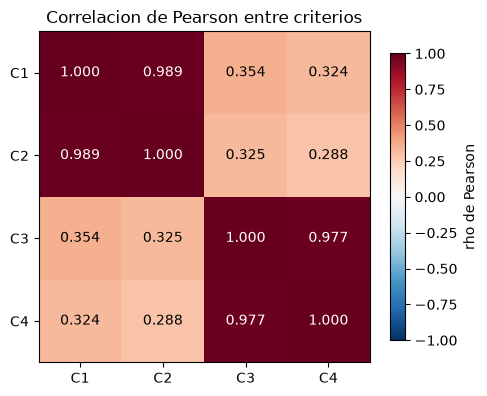

,C1,C2,C3,C4
C1,1.0000,0.9890,0.3540,0.3240
C2,0.9890,1.0000,0.3250,0.2880
C3,0.3540,0.3250,1.0000,0.9770
C4,0.3240,0.2880,0.9770,1.0000


In [16]:
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(matriz_correlacion.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(matriz_correlacion))); ax.set_xticklabels(matriz_correlacion.columns)
ax.set_yticks(range(len(matriz_correlacion))); ax.set_yticklabels(matriz_correlacion.columns)
for i in range(len(matriz_correlacion)):
    for j in range(len(matriz_correlacion)):
        ax.text(j, i, f"{matriz_correlacion.values[i, j]:.3f}", ha="center", va="center",
                color="white" if abs(matriz_correlacion.values[i, j]) > 0.6 else "black")
ax.set_title("Correlacion de Pearson entre criterios")
fig.colorbar(im, ax=ax, shrink=0.8, label="rho de Pearson")
fig.tight_layout()
plt.show()

matriz_correlacion.round(3)


### 2.6 Procedimiento TOPSIS (ecuaciones 7-9)

$$ v_{ij} = w_j r_{ij} \qquad
   A^+ = \{\max_i v_{ij}\},\ A^- = \{\min_i v_{ij}\} \qquad
   S_i^+ = \sqrt{\sum_j (v_{ij}-A_j^+)^2},\ S_i^- = \sqrt{\sum_j (v_{ij}-A_j^-)^2} \qquad
   C_i = \dfrac{S_i^-}{S_i^+ + S_i^-} $$

Los cuatro criterios son de tipo *beneficio*, por lo que la solución ideal es el máximo de cada
columna y la antiideal es el mínimo (no es necesario invertir ninguna columna).

In [17]:
def topsis(R: pd.DataFrame, w: pd.Series) -> pd.Series:
    V = R * w
    A_pos = V.max(axis=0)
    A_neg = V.min(axis=0)
    S_pos = np.sqrt(((V - A_pos) ** 2).sum(axis=1))
    S_neg = np.sqrt(((V - A_neg) ** 2).sum(axis=1))
    Ci = S_neg / (S_pos + S_neg)
    return Ci.sort_values(ascending=False)


ci_entropia = topsis(R, w_entropia)
ci_critic = topsis(R, w_critic)
ci_igual = topsis(R, w_igual)

df_rankings = pd.DataFrame({
    "Ci_Entropia": ci_entropia,
    "Ci_CRITIC": ci_critic,
    "Ci_Igualitario": ci_igual,
})
df_rankings["Rango_Entropia"] = df_rankings["Ci_Entropia"].rank(ascending=False).astype(int)
df_rankings["Rango_CRITIC"] = df_rankings["Ci_CRITIC"].rank(ascending=False).astype(int)
df_rankings["Rango_Igualitario"] = df_rankings["Ci_Igualitario"].rank(ascending=False).astype(int)
df_rankings = df_rankings.sort_values("Rango_Entropia")

df_rankings.round(4).head(12)


,Ci_Entropia,Ci_CRITIC,Ci_Igualitario,Rango_Entropia,Rango_CRITIC,Rango_Igualitario
provincia,,,,,,
Monte Cristi,1.0000,0.9986,0.9989,1,1,1
El Seibo,0.5900,0.5988,0.6004,2,2,2
Puerto Plata,0.5664,0.5775,0.5786,3,3,3
La Altagracia,0.4742,0.4898,0.4907,4,4,4
La Romana,0.4742,0.4889,0.4902,5,5,5
Pedernales,0.3803,0.4016,0.4018,6,6,6
Barahona,0.2830,0.3088,0.3086,7,7,7
San Pedro de Macoris,0.2697,0.2923,0.2935,8,8,8
Azua,0.2480,0.2766,0.2756,9,9,9


### 2.7 Análisis de robustez: correlación de rangos de Spearman (sección 3.8)

In [18]:
rho_critic, _ = spearmanr(df_rankings["Rango_Entropia"], df_rankings["Rango_CRITIC"])
rho_igual, _ = spearmanr(df_rankings["Rango_Entropia"], df_rankings["Rango_Igualitario"])

print(f"Spearman rho (Entropia vs CRITIC)      : {rho_critic:.4f}")
print(f"Spearman rho (Entropia vs Igualitario)  : {rho_igual:.4f}")

diferencias = df_rankings[df_rankings["Rango_Entropia"] != df_rankings["Rango_CRITIC"]]
print(f"\nProvincias cuyo rango difiere entre Entropia y CRITIC: {len(diferencias)}")
diferencias[["Rango_Entropia", "Rango_CRITIC"]]


Spearman rho (Entropia vs CRITIC)      : 0.9996
Spearman rho (Entropia vs Igualitario)  : 1.0000

Provincias cuyo rango difiere entre Entropia y CRITIC: 2


,Rango_Entropia,Rango_CRITIC
provincia,,
Hermanas Mirabal,29,30
Elias Pina,30,29


### 2.8 Ranking completo de las 32 provincias (Apéndice B del artículo)

In [19]:
apendice_b = df_rankings.copy()
apendice_b.index.name = "Provincia"
apendice_b.round(4)


,Ci_Entropia,Ci_CRITIC,Ci_Igualitario,Rango_Entropia,Rango_CRITIC,Rango_Igualitario
Provincia,,,,,,
Monte Cristi,1.0000,0.9986,0.9989,1,1,1
El Seibo,0.5900,0.5988,0.6004,2,2,2
Puerto Plata,0.5664,0.5775,0.5786,3,3,3
La Altagracia,0.4742,0.4898,0.4907,4,4,4
La Romana,0.4742,0.4889,0.4902,5,5,5
Pedernales,0.3803,0.4016,0.4018,6,6,6
Barahona,0.2830,0.3088,0.3086,7,7,7
San Pedro de Macoris,0.2697,0.2923,0.2935,8,8,8
Azua,0.2480,0.2766,0.2756,9,9,9


## PARTE 3 — Visualización

### 3.1 Figura 1: ranking multicriterio del potencial solar-eólico (Entropía-TOPSIS)

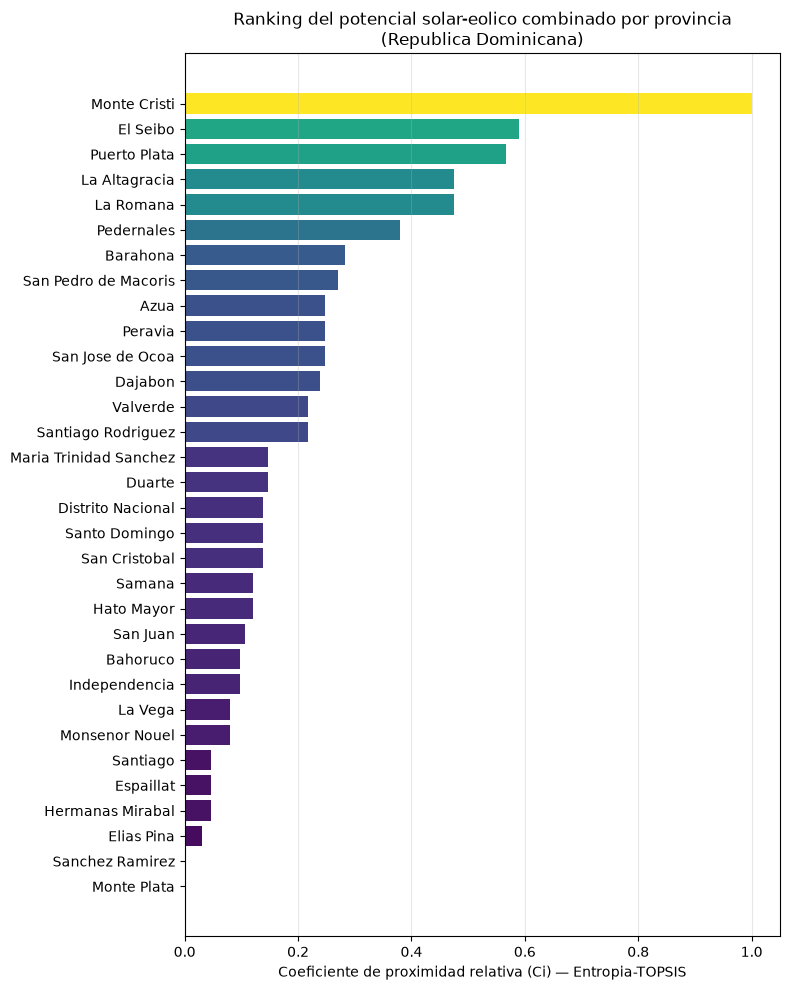

In [20]:
fig, ax = plt.subplots(figsize=(8, 10))
orden = df_rankings.sort_values("Ci_Entropia")
colores = plt.cm.viridis(orden["Ci_Entropia"] / orden["Ci_Entropia"].max())
ax.barh(orden.index, orden["Ci_Entropia"], color=colores)
ax.set_xlabel("Coeficiente de proximidad relativa (Ci) — Entropia-TOPSIS")
ax.set_title("Ranking del potencial solar-eolico combinado por provincia\n(Republica Dominicana)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.savefig(OUT_DIR / "figura1_ranking_entropia_topsis.png", dpi=150)
plt.show()


### 3.2 Comparación de esquemas de ponderación

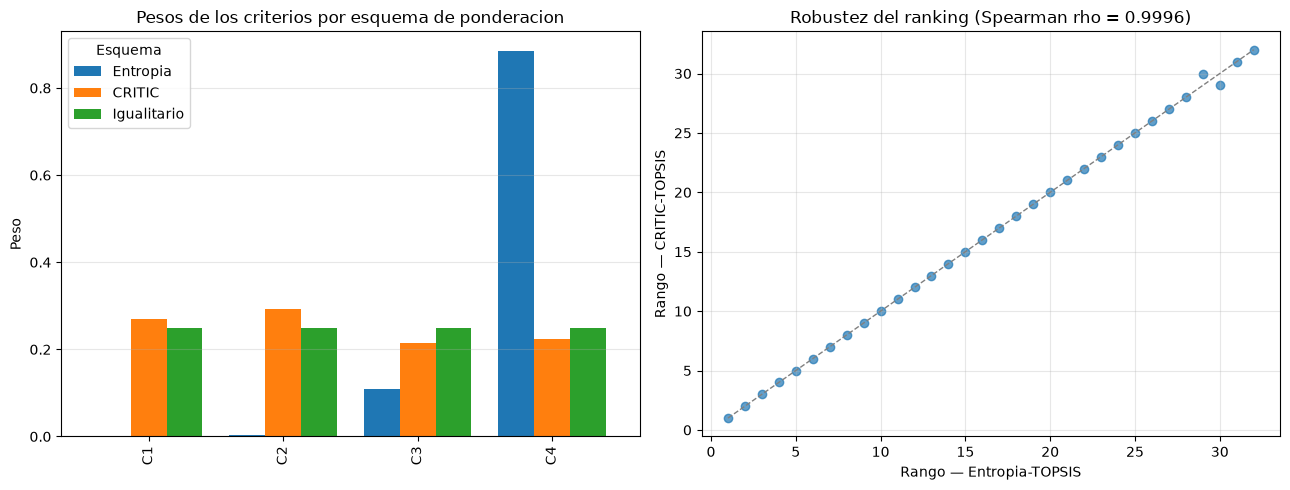

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tabla3.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("Pesos de los criterios por esquema de ponderacion")
axes[0].set_ylabel("Peso")
axes[0].legend(title="Esquema")
axes[0].grid(axis="y", alpha=0.3)

axes[1].scatter(df_rankings["Rango_Entropia"], df_rankings["Rango_CRITIC"], alpha=0.7)
lims = [1, 32]
axes[1].plot(lims, lims, "--", color="gray", linewidth=1)
axes[1].set_xlabel("Rango — Entropia-TOPSIS")
axes[1].set_ylabel("Rango — CRITIC-TOPSIS")
axes[1].set_title(f"Robustez del ranking (Spearman rho = {rho_critic:.4f})")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.savefig(OUT_DIR / "figura_pesos_y_robustez.png", dpi=150)
plt.show()


### 3.3 Dispersión del recurso solar vs. eólico, coloreada por el ranking

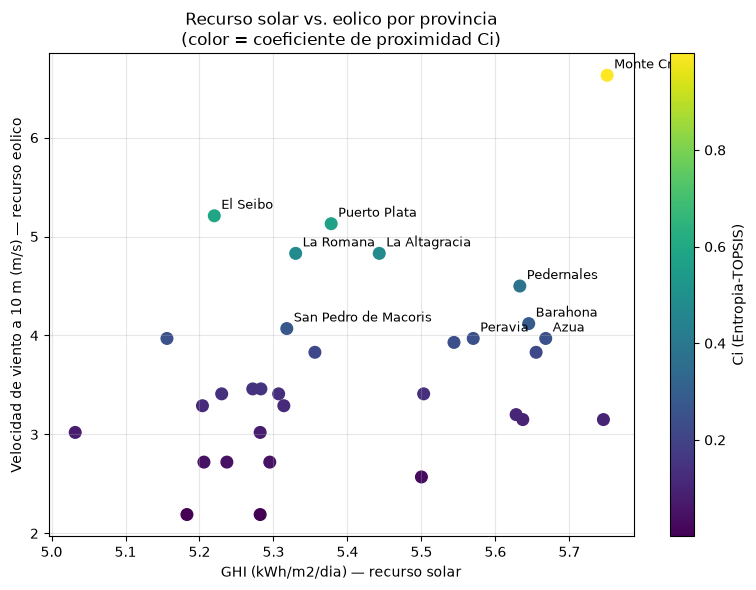

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X["C1"], X["C3"], c=df_rankings.loc[X.index, "Ci_Entropia"], cmap="viridis", s=70)
top5 = df_rankings.head(10).index
for prov in top5:
    ax.annotate(prov, (X.loc[prov, "C1"], X.loc[prov, "C3"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("GHI (kWh/m2/dia) — recurso solar")
ax.set_ylabel("Velocidad de viento a 10 m (m/s) — recurso eolico")
ax.set_title("Recurso solar vs. eolico por provincia\n(color = coeficiente de proximidad Ci)")
fig.colorbar(sc, ax=ax, label="Ci (Entropia-TOPSIS)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig(OUT_DIR / "figura_dispersion_solar_eolico.png", dpi=150)
plt.show()


## PARTE 4 — Exportación de resultados

Se exportan la matriz de decisión, los pesos, el ranking completo (Apéndice B) y la matriz de
correlación a un único libro de Excel, además de los CSV individuales, en la carpeta `outputs/`.

In [23]:
with  pd.ExcelWriter(OUT_DIR / "resultados_ranking_solar_eolico_RD.xlsx", engine='xlsxwriter') as writer:
    df_decision.to_excel(writer, sheet_name="Matriz_decision")
    tabla1.to_excel(writer, sheet_name="Estadistica_descriptiva")
    tabla3.to_excel(writer, sheet_name="Pesos_criterios")
    matriz_correlacion.to_excel(writer, sheet_name="Correlacion_Pearson")
    apendice_b.to_excel(writer, sheet_name="Ranking_completo_32_prov")
    if df_generacion_fuente is not None:
        df_generacion_fuente.to_excel(writer, sheet_name="Generacion_por_fuente_SIEN")
    if not df_parques_eolicos.empty:
        df_parques_eolicos.to_excel(writer, sheet_name="Generacion_parques_eolicos", index=False)

apendice_b.to_csv(OUT_DIR / "apendice_b_ranking_completo.csv", encoding="utf-8-sig")

print("Archivos exportados en:", OUT_DIR.resolve())
for f in sorted(OUT_DIR.iterdir()):
    print(" -", f.name)


Archivos exportados en: C:\Users\gypsa\enerlac\outputs
 - apendice_b_ranking_completo.csv
 - figura1_ranking_entropia_topsis.png
 - figura_dispersion_solar_eolico.png
 - figura_pesos_y_robustez.png
 - matriz_decision_32_provincias.csv
 - resultados_ranking_solar_eolico_RD.xlsx
